In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
x_train = np.load(r'datasets/mnist/x_train.npy')

In [3]:
x_test = np.load('datasets/mnist/x_test.npy')
y_test = np.load('datasets/mnist/y_test.npy')
y_train = np.load('datasets/mnist/y_train.npy')


In [4]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [5]:
x_train[0].shape

(28, 28)

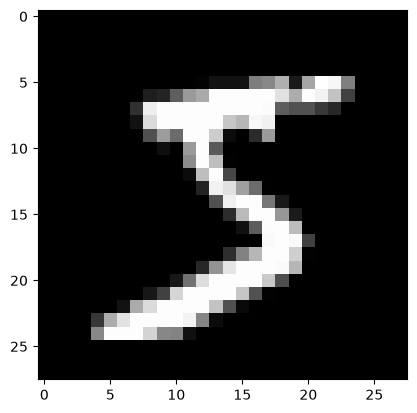

In [6]:
plt.imshow(x_train[0], cmap = 'gray');

In [7]:
y_train[0]

np.uint8(5)

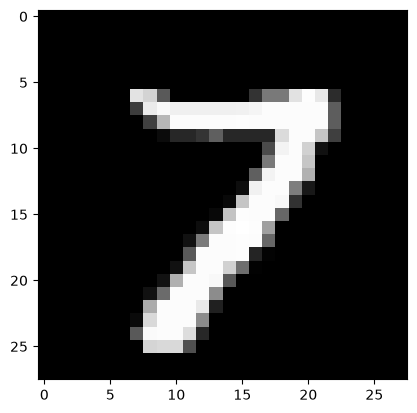

In [8]:
plt.imshow(x_test[34], cmap = 'gray');

In [9]:
y_test[34]

np.uint8(7)

In [10]:
28 * 28

784

In [11]:
x_train.shape

(60000, 28, 28)

In [12]:
z = np.array([[1,2,3], [3,4,5]])

In [13]:
z

array([[1, 2, 3],
       [3, 4, 5]])

In [14]:
z.flatten()

array([1, 2, 3, 3, 4, 5])

In [15]:
img = x_train[1]

In [16]:
img.shape

(28, 28)

In [17]:
img.flatten().shape

(784,)

In [18]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

In [19]:
# normalize the pixel value

In [20]:
x_train = x_train / 255
x_test = x_test / 255

In [21]:
x_train.shape

(60000, 784)

In [22]:
# check the distribution of target variables
# ==> plot the bar graph showing the frequency of target variable in 
# training data

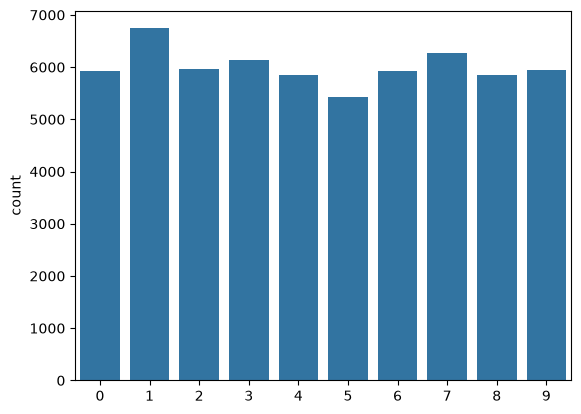

In [23]:
sns.countplot(x = y_train);

In [24]:
# ohe

a = [2, 2, 1, 1, 0, 2]

In [25]:
from keras.utils import to_categorical

2026-09-29 09:39:03.122206: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-29 09:39:03.146658: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-29 09:39:03.323283: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-29 09:39:03.457676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790654943.574486    3251 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790654943.60

In [26]:
to_categorical(a)

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [27]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [28]:
from keras.layers import Dense
from keras.optimizers import SGD
from keras.models import Sequential

In [29]:
x_train.shape[1]

784

In [30]:
import warnings
warnings.filterwarnings('ignore')

In [37]:
model = Sequential()

model.add(Dense(128, input_shape = (784,),activation = 'relu'))
model.add(Dense(68, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))

In [38]:
# help(model.add)

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 68)             │         8,772 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,942 (429.46 KB)

 Trainable params: 109,942 (429.46 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from keras.optimizers import SGD

In [41]:
# compile the model

model.compile(loss = 'categorical_crossentropy',
             optimizer = SGD(learning_rate= 0.001),
             metrics = ['accuracy'])

In [42]:
history = model.fit(x_train, y_train, epochs = 30, batch_size = 100)

Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2859 - loss: 2.1388
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6226 - loss: 1.7915
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7253 - loss: 1.4228
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7704 - loss: 1.1166
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8001 - loss: 0.9072
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8206 - loss: 0.7720
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8349 - loss: 0.6818
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8464 - loss: 0.6183
Epoch 9/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8553 - loss: 0.5712
Epoch 10/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8621 - loss: 0.5348
Epoch 11/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8678 - loss: 0.5057
Epoch 12/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

In [43]:
model.weights[0]

<Variable path=sequential_1/dense_3/kernel, shape=(784, 128), dtype=float32, value=[[-0.01857842  0.02494581  0.01674537 ...  0.01160269  0.01148474
   0.03807657]
 [ 0.019672    0.00562669 -0.006789   ...  0.02896628 -0.04045513
   0.02197658]
 [ 0.01050389  0.01826882 -0.06774644 ... -0.00416911 -0.05150161
   0.07124455]
 ...
 [-0.07887746 -0.04658413  0.0315134  ... -0.05517221 -0.04316605
  -0.04008917]
 [-0.08074887  0.05476569  0.01963539 ...  0.03822954  0.07275916
  -0.00558283]
 [-0.07270715 -0.04631623 -0.02296926 ... -0.02479532 -0.00621568
   0.04377998]]>

In [45]:
history.history
# plot line chart to check epoch by epoch -> accuracy and loss

{'accuracy': [0.28593334555625916,
  0.6226166486740112,
  0.7253000140190125,
  0.7704333066940308,
  0.8001333475112915,
  0.8205666542053223,
  0.8349000215530396,
  0.8464333415031433,
  0.8552500009536743,
  0.8620833158493042,
  0.8677999973297119,
  0.8729666471481323,
  0.8770666718482971,
  0.8808500170707703,
  0.8842166662216187,
  0.8870499730110168,
  0.8894166946411133,
  0.8915333151817322,
  0.8930833339691162,
  0.8946166634559631,
  0.8968833088874817,
  0.8978999853134155,
  0.899649977684021,
  0.9010499715805054,
  0.9020166397094727,
  0.9032666683197021,
  0.9043999910354614,
  0.9055333137512207,
  0.9065499901771545,
  0.9077666401863098],
 'loss': [2.1387875080108643,
  1.7915295362472534,
  1.422761082649231,
  1.1166458129882812,
  0.9072461128234863,
  0.7719755172729492,
  0.6818139553070068,
  0.6182874441146851,
  0.5711653232574463,
  0.5347610712051392,
  0.5056892037391663,
  0.4820370674133301,
  0.46231481432914734,
  0.44560810923576355,
  0.431183

In [46]:
data = history.history

In [48]:
len(data['accuracy'])

30

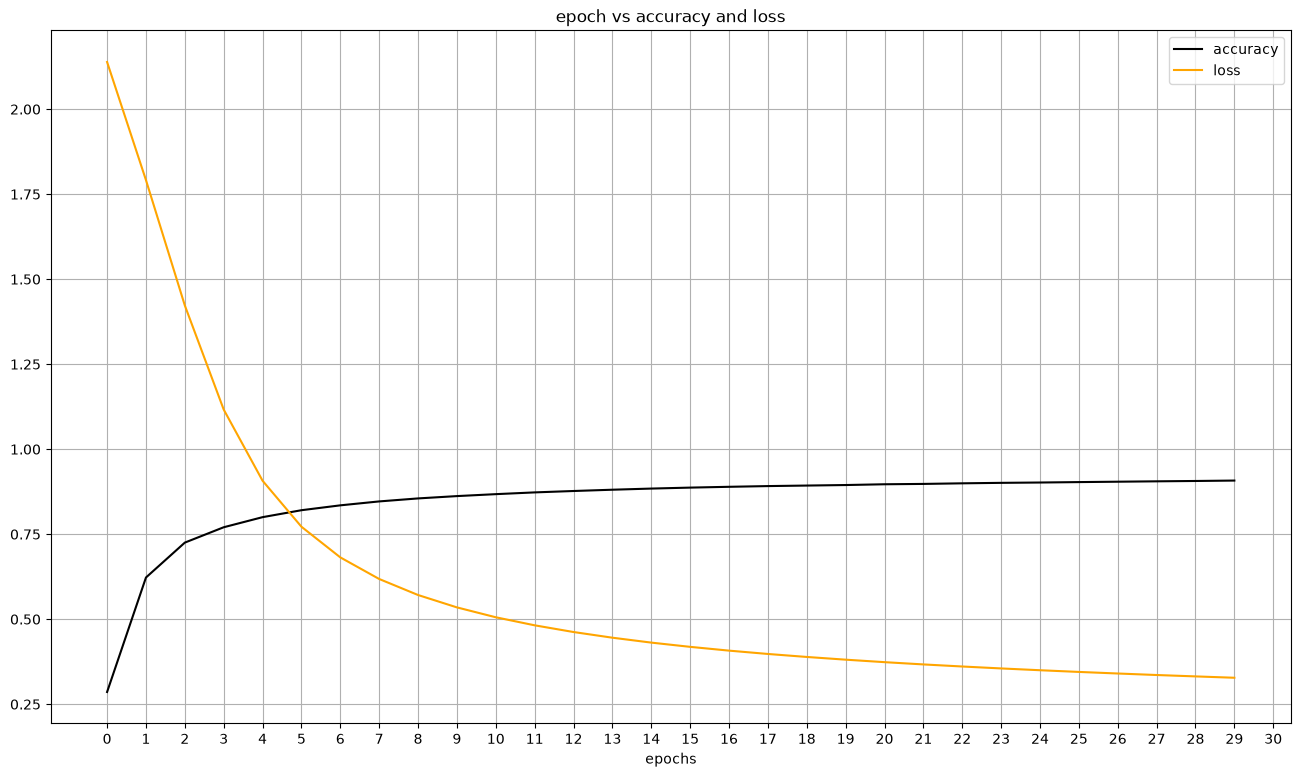

In [53]:
plt.figure(figsize=(16, 9))
plt.title('epoch vs accuracy and loss')
plt.xlabel('epochs')
plt.xticks(range(0, 31, 1))
plt.plot(range(30), data['accuracy'], label = 'accuracy', color = 'black');
plt.plot(range(30), data['loss'], label = 'loss', color = 'orange');
plt.legend()
plt.grid();